In [ ]:
!pip install sentence-transformers seaborn matplotlib scikit-learn

  Using cached sentence_transformers-5.4.1-py3-none-any.whl.metadata (17 kB)
  Using cached transformers-5.5.4-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.11.0-py3-none-any.whl.metadata (14 kB)
  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached regex-2026.4.4-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.4.3-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
Using cached sentence_transformers-5.4.1-py3-none-any.whl (571 kB)
Using cached transformers-5.5.4-py3-none-any.whl (10.2 MB)
Using cached huggingface_hub-1.11.0-py3-none-any.whl (645 kB)
Using cached hf_xet-1.4.3-cp37-abi3-win_amd64.whl (3.7 MB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached regex-2026.4.4-cp313-cp313-win_amd64.whl (277 kB)
Using cached safetensors-0.7.0-cp38-abi3-win_

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'C:\\Users\\shiva\\anaconda3\\Lib\\site-packages\\transformers\\models\\janus\\modeling_janus.py'
Consider using the `--user` option or check the permissions.



   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   ------------------ --------------------- 262.1/571.3 kB ? eta -:--:--
   -------------------------------------- 571.3/571.3 kB 804.9 kB/s eta 0:00:00
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.2 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/10.2 MB 1.4 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/10.2 MB 1.5 MB/s eta 0:00:07
   ------ --------------------------------- 1.6/10.2 MB 1.6 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/10.2 MB 1.6 MB/s eta 0:00:06
   --------- ------------------------

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
sentences = [

# Cricket
"The batsman scored a century in the final match.",
"The bowler delivered a fast yorker to dismiss the player.",
"The cricket team celebrated their victory after a thrilling game.",
"The bowler took three wickets in one over.",

# Cooking
"I prepared a delicious pasta with fresh vegetables.",
"The chef added spices to enhance the flavor of the curry.",
"Baking a chocolate cake requires precise measurements.",

# Cybersecurity
"Cybersecurity protects systems from digital attacks.",
"Strong passwords help prevent unauthorized access.",
"Encryption ensures that sensitive data remains secure."

]

In [5]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\shiva\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shiva\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
embeddings = model.encode(sentences)

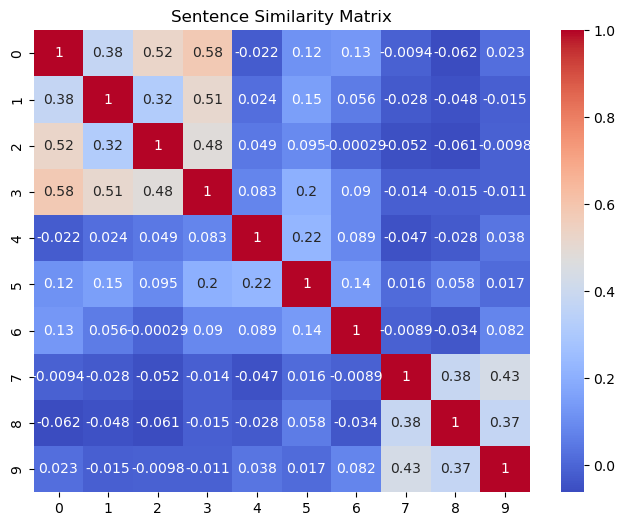

In [7]:
similarity_matrix = cosine_similarity(embeddings)

df = pd.DataFrame(similarity_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(df, annot=True, cmap="coolwarm")
plt.title("Sentence Similarity Matrix")
plt.show()

In [8]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

scores = cosine_similarity(query_embedding, embeddings)[0]

results = list(zip(sentences, scores))

results = sorted(results, key=lambda x: x[1], reverse=True)

print("Top 2 most similar sentences:\n")

for sentence, score in results[:2]:
    print(sentence, " --> similarity:", round(score,3))

Top 2 most similar sentences:

The bowler took three wickets in one over.  --> similarity: 0.991
The batsman scored a century in the final match.  --> similarity: 0.568
